In [1]:
from Parameterize import *
import nglview as ng

https://github.com/marrink-lab/martini-forcefields/blob/main/martini_forcefields/regular/v3.0.0/gmx_files/martini_v3.0.0_sugars_v2.itp

https://github.com/marrink-lab/martini-forcefields/tree/main/martini_forcefields/regular/v3.0.0/gmx_files

https://github.com/marrink-lab/polyply_1.0/blob/master/polyply/data/martini3/dextran.martini3.ff

In [2]:
main_dir   = '/data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims' #Main working directory, where the AA simulations are located as well
mdp_loc_BL = '/data1/lisbeth/Params/BILAYERS/MDPs' #This is default
mdp_loc    = '/data1/lisbeth/Params/FRAGMENTS/AA_SIMS_WATER_IONS/MDPs'

## AA sim
GRO = 'Resid_1.pdb'
XTC = 'Resid_all.xtc'

I had to provide random numbers to the atoms and then include the sugars in the same resid as the rest of the lipid. I then made the simulation while with -pbc nojump, after which I wrote out every resid individually, and then cat them together again, such that I could use the pdb of just resid 1.

### Manual stuff : you will need to make the mapping and define bonds and angles. The optimization of the bonded parameters you can do iteratively

In [3]:
os.chdir(main_dir)

In [4]:
#Load atomistic universe
#u = md.Universe(GRO, XTC)
u = md.Universe(GRO)

/home/lravnkilde/.conda/envs/neglview/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:317: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


In [5]:
resname = np.unique(u.select_atoms('all and not resname TIP3 POPC and not name SOD CLA').resnames)[0]

In [6]:
sel = u.select_atoms('resname {} and resid 1'.format(resname))

In [7]:
# sele = u.select_atoms('all')
# with md.selections.gromacs.SelectionWriter('selection.ndx', mode='w') as ndx:
#     for res in np.unique(sele.resids):
#         r = u.select_atoms('resid {}'.format(res))
#         ndx.write(r, name='Resid_{}'.format(res))

In [8]:
ng.show_mdanalysis(sel)

NGLWidget()

In [9]:
#Make AA sims whole for later 
#os.system('echo 0 | gmx trjconv -s {} -f {} -pbc nojump -o AA_whole.xtc'.format(GRO, XTC))

### Define mapping

In [9]:
#Define manually
#resname = 'DLKC'
A = ['C310','H767','C306','H386','O102','H789']
B = ['C891','H684','O374','H882','C790','H631','O94','H124']
C = ['C20','H303','C731','H960','H252','O212','H24','O460']

Aa = ['C827','H786','C788','H463','O612','H155']
Bb = ['C846','H567','O494','H255','C914','H727','O707']
Cc = ['C302','O48','H12']
Dd = ['C227','O920','O628']

Aaa = ['C123','H147','C90','H262','O47','H326']
Bbb = ['C948','H179','O547','C444','H842','O889','H476']
Ccc = ['C153','H817','O278','H336','C470,','H446','O484','H454']

PO4 = ['O82','P7','O720','O728','O712']
NOH = ['C941','N66','H984','C414','O956','H258']
GLA = ['C294','H36','O538','H111','C442','H265']

VS1 = ['C310','H767','C306','H386','O102','H789', 'C891','H684','O374','H882','C790','H631','O94','H124', 'C20','H303','C731','H960','H252','O212','H24','O460']
VS2 = ['C827','H786','C788','H463','O612','H155','C846','H567','O494','H255','C914','H727','O707','C302','O48','H12']
VS3 = ['C123','H147','C90','H262','O47','H326','C948','H179','O547','C444','H842','O889','H476','C153','H817','O278','H336','C470,','H446','O484','H454']

bead_assignments = [A,       B,     C,     Aa,    Bb,     Cc,      Dd,     Aaa,   Bbb,    Ccc,   PO4,   NOH,    GLA,  VS1, VS2, VS3]
bead_types       = ['SN6','SP4r','SP1r',  'SN6', 'SP1r', 'TN4ar', 'SQ5n', 'SN6', 'SP1r', 'SP4r', 'Q5', 'SP3d', 'SN4a', 'TC4', 'TC4', 'TC4']
bead_names       = ['A',    'B',    'C',   'Aa', 'Bb',   'Cc',    'Dd',   'Aaa', 'Bbb',  'Ccc',  'PO4', 'NOH', 'GLA',  'VS1', 'VS2', 'VS3']
bead_sizes       = ['S',     'S',  'S',    'S',   'S',    'T',     'S',   'S',   'S',    'S',    'R',  'S',    'S', 'T', 'T','T']
bead_charges     = [0,        0,    0,      0,     0,      0,       -1,    0,     0,      0,     -1 ,   0,     0 ,0,0,0]

In [10]:
flat_list = [item for sublist in bead_assignments for item in sublist]

In [11]:
all_AA_atoms = ' '.join('{}'.format(i) for i in flat_list)

In [12]:
selection_special = 'name {}'.format(all_AA_atoms)

### Define angles, bonds, and possible dihedrals

In [20]:
#define manually
ang_tgts = [['Aa','Cc','Dd'],#0
           ['B','A','Bb'],#1
           ['Bb','Aa','Bbb'],#2
           ['Cc','Aa','Bbb'],#3
           ['Aa','Bbb','Ccc'],#4
           ['Aa','Bbb','Aaa'],#5
           ['Aaa','PO4','NOH'],#6
           ['Aaa','PO4','GLA'],#7
           ['Bbb','Aaa','PO4'],#8
           ['Bbb','Ccc','PO4'],#9
           ['Bbb','Ccc','Aaa'],#10
           ['Aaa','Bbb','Ccc'],#11
           ['Ccc','Aaa','Bbb'],#12
           #['Ddd','Ccc','Aaa'],#13
           ['Ccc','Aaa','PO4'],#14
           ['A','Bb','Cc'],#15
           ['C','A','B'],#16
           ['A','B','Bb'],#17
           ['C','Bb','Aa'],#18
           ['C','A','Bb'],#19
           ['Aaa','Bbb','Aa']]#20

dist_tgts = [['A','B'],
            ['A','C'],
            ['B','C'],
            ['Aa','Bb'],
            ['Aa','Cc'],
            ['Bb','Cc'],
            ['Cc','Dd'],
            ['Bbb','Aaa'],
            ['Bbb','Ccc'],
            ['Aaa','Ccc'],
            ['Aa','Bbb'],
            ['A','Bb'],
            ['Aaa','PO4'], ['PO4','NOH'], ['PO4','GLA']]

# dihed_tgts = [['Dd' ,'Aa' ,'Bb' ,'Cc'],
#              ['Bb', 'Aa', 'Bbb', 'Aaa'],
#              ['Bbb', 'Aaa', 'PO4', 'NOH'],
#              ['B', 'A', 'Bb', 'Aa'],
#              [ 'C', 'A', 'Bb', 'Cc' ],
#              [ 'C' ,'A' ,'Bb' ,'Aa'],
#              ['C','B','A','Bb'], #improper 1
#               ['C','B','A','Cc'],
#                ['C','B','A','Dd'],
#              ['Cc','Bb','Aa','Bbb'],
#              ['Bbb','Ccc','Aaa','PO4'],
#              ['C','Bb','Aa','Bbb'],
#              ['Dd','Cc','Aa','Bbb'],
#              ['Cc','Bb','Aa','Bbb'],#improper 3
#               ['Cc','Aa','Bb','A'],#improper 2
#               ['Ccc','Aaa','Bbb','Aa'],#improper 4
#               ['VS1','A','Bb','VS2'],
#               ['VS2','Aa','Bbb','VS3'],
#              ]


dihed_tgts = [
             ['C','B','A','Bb'], #improper 1
             ['Cc','Bb','Aa','Bbb'],#improper 3
              ['Cc','Aa','Bb','A'],#improper 2
              ['Ccc','Aaa','Bbb','Aa'],#improper 4
              ['VS1','A','Bb','VS2'],
              ['VS2','Aa','Bbb','VS3'],
              ['Bbb','Aaa','PO4','NOH'],
              ['Bb','Aa','Bbb','Ccc'],
              ['B','A','Bb','Aa']
             ]


D_ang, D_bond = make_angle_bond_dicts(ang_tgts, dist_tgts, bead_names)

bins_dihed = np.arange(-181,181,2)
bins_angl = np.arange(-1,181,2)
bins_dist = np.arange(0,15,0.2)

bins_dihed_x = (bins_dihed[1:] + bins_dihed[:-1]) / 2
bins_angl_x = (bins_angl[1:] + bins_angl[:-1]) / 2
bins_dist_x = (bins_dist[1:] + bins_dist[:-1]) / 2


List_angles = [[0],[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11],[12],[13],[14],[15],[16],[17],[18],[19]]

List_bonds =[[0],[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11],[12],[13],[14]]

#List_dihed = [[0],[1],[2],[3],[4],[5], [6],[7],[8], [9] ,[10],[11] ,[12], [13],[14],[15],[16],[17]] 
List_dihed = [[0],[1],[2],[3],[4],[5], [6], [7] , [8]] 

In [21]:
ang_tgts

[['Aa', 'Cc', 'Dd'],
 ['B', 'A', 'Bb'],
 ['Bb', 'Aa', 'Bbb'],
 ['Cc', 'Aa', 'Bbb'],
 ['Aa', 'Bbb', 'Ccc'],
 ['Aa', 'Bbb', 'Aaa'],
 ['Aaa', 'PO4', 'NOH'],
 ['Aaa', 'PO4', 'GLA'],
 ['Bbb', 'Aaa', 'PO4'],
 ['Bbb', 'Ccc', 'PO4'],
 ['Bbb', 'Ccc', 'Aaa'],
 ['Aaa', 'Bbb', 'Ccc'],
 ['Ccc', 'Aaa', 'Bbb'],
 ['Ccc', 'Aaa', 'PO4'],
 ['A', 'Bb', 'Cc'],
 ['C', 'A', 'B'],
 ['A', 'B', 'Bb'],
 ['C', 'Bb', 'Aa'],
 ['C', 'A', 'Bb'],
 ['Aaa', 'Bbb', 'Aa']]

## map from aa to cg

In [16]:
map_aa2cg(u, resname, bead_assignments, bead_names, bead_sizes, 'AA_whole.xtc', GRO)

                       :-) GROMACS - gmx traj, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szilard Pall   
    Sander Pronk      Roland Schulz      Michael Shirts    Alexey Shvetsov  
   Alfons Sijbers     Peter Tieleman      Jon Vincent      Teemu Virolainen 
 Christian Wennberg    Maarten Wolf      Artem Zhmurov   
                           and the project leaders:
      


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

Selected 0: 'mdanalysis001'
Selected 1: 'mdanalysis002'
Selected 2: 'mdanalysis003'
Selected 3: 'mdanalysis004'
Selected 4: 'mdanalysis005'
Selected 5: 'mdanalysis006'
Selected 6: 'mdanalysis007'
Selected 7: 'mdanalysis008'
Selected 8: 'mdanalysis009'
Selected 9: 'mdanalysis010'
Selected 10: 'mdanalysis011'
Selected 11: 'mdanalysis012'
Selected 12: 'mdanalysis013'
Selected 13: 'mdanalysis014'
Selected 14: 'mdanalysis015'
Selected 15: 'mdanalysis016'


Reading frame   19000 time 1900000.000   


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

Selected 0: 'mdanalysis001'
Selected 1: 'mdanalysis002'
Selected 2: 'mdanalysis003'
Selected 3: 'mdanalysis004'
Selected 4: 'mdanalysis005'
Selected 5: 'mdanalysis006'
Selected 6: 'mdanalysis007'
Selected 7: 'mdanalysis008'
Selected 8: 'mdanalysis009'
Selected 9: 'mdanalysis010'
Selected 10: 'mdanalysis011'
Selected 11: 'mdanalysis012'
Selected 12: 'mdanalysis013'
Selected 13: 'mdanalysis014'
Selected 14: 'mdanalysis015'
Selected 15: 'mdanalysis016'


Last frame      20000 time 2000000.000   

GROMACS reminds you: "Sometimes Life is Obscene" (Black Crowes)



### initial SASA

In [130]:
CG  = ['cg_good.gro', #GRO
       'cg.xtc']      #XTC
AA = [GRO,XTC]

In [13]:
os.chdir(main_dir)
run_SASA('CG', CG, resname, main_dir, bead_names, bead_sizes)

/home/lravnkilde/.conda/envs/neglview/lib/python3.10/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: A
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/home/lravnkilde/.conda/envs/neglview/lib/python3.10/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: D
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/home/lravnkilde/.conda/envs/neglview/lib/python3.10/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: G
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
                       :-) GROMACS - gmx sasa, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
   

entering /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/CG

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- ----

Reading frame   19000 time 1900000.000   


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- -------- --------



Last frame      20000 time 2000000.000   
Analyzed 20001 frames, last time 2000000.000

GROMACS reminds you: "The Lord of the Rings can be confusing to follow because many of the bad minions look and sound familiar; that's why Tolkien gave them each an ORCid." (Caroline Bartman)

                       :-) GROMACS - gmx sasa, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szila

In [17]:
os.chdir(main_dir)
run_SASA('AA', AA, resname, main_dir, bead_names, bead_sizes, selection=selection_special)
#Im only mapping the sugars and linker, so Im only doing the SASA calculation of the beads Im mapping for comparison. 

/home/lravnkilde/.conda/envs/neglview/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:317: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
                       :-) GROMACS - gmx sasa, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz   

entering /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/AA

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- ----

Reading frame  240000 time 1998900.000   

Back Off! I just backed up /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/AA/resarea_SASA.xvg to /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/AA/#resarea_SASA.xvg.1#
Analyzed 240012 frames, last time 2000000.000

GROMACS reminds you: "It all works because Avogadro's number is closer to infinity than to 10." (Ralph Baierlein)




         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- -------- --------



                       :-) GROMACS - gmx sasa, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szilard Pall   
    Sander Pronk      Roland Schulz      Michael Shirts    Alexey Shvetsov  
   Alfons Sijbers     Peter Tieleman      Jon Vincent      Teemu Virolainen 
 Christian Wennberg    Maarten Wolf      Artem Zhmurov   
                           and the project leaders:
      

SASA AA: [9.722 0.169]
SASA CG: [9.126 0.126]
percent difference between the models.
6.130425838304876


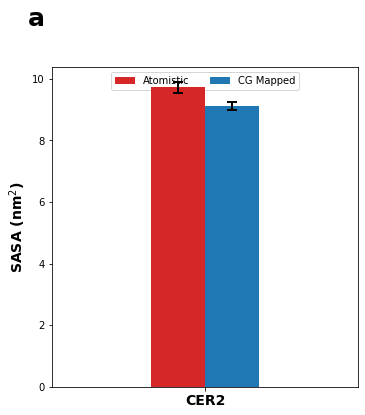

In [18]:
CG_xvg = '{}/CG/resarea_SASA.xvg'.format(main_dir)
AA_xvg = '{}/AA/resarea_SASA.xvg'.format(main_dir)

SASA_CG, SASA_AA =  plot_SASA(AA_xvg, CG_xvg, resname)

## CG in water w. 0.15 M NaCl

In [17]:
#os.mkdir('CG_WAT')
os.chdir('{}/CG_WAT'.format(main_dir))
#os.system('cp ../cg_good.gro .') 

### write an initial itp CG

In [24]:
# #Write an initial CG itp file. You will of course need to set bond lengt, angles and so forth, but the rest is there
#write_initial_CGitp3(resname, bead_names, bead_sizes, bead_types, bead_charges, D_bond, D_ang, dist_tgts, ang_tgts)

#### Setup sydtem and run for a small period of time

In [33]:
#prepare_setup_water(mdp_loc)
re_run(resname, mdp_loc, maxwarn=5)

                      :-) GROMACS - gmx grompp, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szilard Pall   
    Sander Pronk      Roland Schulz      Michael Shirts    Alexey Shvetsov  
   Alfons Sijbers     Peter Tieleman      Jon Vincent      Teemu Virolainen 
 Christian Wennberg    Maarten Wolf      Artem Zhmurov   
                           and the project leaders:
     

Analysing residue names:
There are:  1194      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
This run will generate roughly 25 Mb of data


Reading file m.tpr, VERSION 2020.7 (single precision)

NOTE: Parallelization is limited by the small number of atoms,
      only starting 1 thread-MPI ranks.
      You can use the -nt and/or -ntmpi option to optimize the number of threads.

1 GPU selected for this run.
Mapping of GPU IDs to the 1 GPU task in the 1 rank on this node:
  PP:0
PP tasks will do (non-perturbed) short-ranged interactions on the GPU
PP task will update and constrain coordinates on the CPU
Using 1 MPI thread

Non-default thread affinity set, disabling internal thread affinity

Using 32 OpenMP threads 


Back Off! I just backed up m.trr to ./#m.trr.1#

Back Off! I just backed up m.edr to ./#m.edr.1#

Steepest Descents:
   Tolerance (Fmax)   =  1.00000e+01
   Number of steps    =      1000000
Step=    0, Dmax= 1.0e-02 nm, Epot=  7.33502e+06 Fmax= 1.66869e+07, atom= 1177
Step=    1, Dmax= 1.0e-02 nm, Epot=  5.00240e+06 Fmax= 7.12875e+06, atom= 622
Step=    2, Dmax= 1.2e-02 nm, Epot=  3.24754e+06 Fmax= 3.47632e+06,

Analysing residue names:
There are:  1194      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 310 K
Calculated rlist for 1x1 atom pair-list as 1.187 nm, buffer size 0.087 nm
Set rlist, assuming 4x4 atom pair-list, to 1.142 nm, buffer size 0.042 nm
Note that mdrun will redetermine rlist based on the actual pair-list setup
This run will generate roughly 69 Mb of data


Reading file r.tpr, VERSION 2020.7 (single precision)
Changing nstlist from 20 to 50, rlist from 1.142 to 1.28

1 GPU selected for this run.
Mapping of GPU IDs to the 1 GPU task in the 1 rank on this node:
  PP:0
PP tasks will do (non-perturbed) short-ranged interactions on the GPU
PP task will update and constrain coordinates on the CPU
Using 1 MPI thread

Non-default thread affinity set, disabling internal thread affinity

Using 10 OpenMP threads 


Back Off! I just backed up r.xtc to ./#r.xtc.1#

Back Off! I just backed up r.edr to ./#r.edr.1#
starting mdrun 'one molecule in water'
1000000 steps,  10000.0 ps.
step 999900, remaining wall clock time:     0 s          
Writing final coordinates.

Back Off! I just backed up r.gro to ./#r.gro.1#
step 1000000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:     1142.655      114.266     1000.0
                 (ns/day)    (hour/ns)
Performance:     7561.331        0.003

GROMACS 

In [34]:
#os.system('gmx grompp -f run-crasher.mdp -c r.gro')
os.system('gmx grompp -f run.mdp -c r.gro -o p.tpr')

#os.system('gmx mdrun -v -deffnm p -nt  10 -pin on -pinoffset 0 -pinstride 1')

                      :-) GROMACS - gmx grompp, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szilard Pall   
    Sander Pronk      Roland Schulz      Michael Shirts    Alexey Shvetsov  
   Alfons Sijbers     Peter Tieleman      Jon Vincent      Teemu Virolainen 
 Christian Wennberg    Maarten Wolf      Artem Zhmurov   
                           and the project leaders:
     

Analysing residue names:
There are:  1194      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Determining Verlet buffer for a tolerance of 0.002 kJ/mol/ps at 310 K
Calculated rlist for 1x1 atom pair-list as 1.484 nm, buffer size 0.384 nm
Set rlist, assuming 4x4 atom pair-list, to 1.369 nm, buffer size 0.269 nm
Note that mdrun will redetermine rlist based on the actual pair-list setup
This run will generate roughly 1462 Mb of data


Generated 844 of the 356590 non-bonded parameter combinations
Excluding 1 bonded neighbours molecule type 'CER2'
Excluding 1 bonded neighbours molecule type 'W'
Excluding 1 bonded neighbours molecule type 'NA'
Excluding 1 bonded neighbours molecule type 'CL'
Excluding 1 bonded neighbours molecule type 'NA'
Cleaning up constraints and constant bonded interactions with virtual sites
Removed      1        G96Angles with virtual sites, 9 left
Number of degrees of freedom in T-Coupling group System is 3603.00

NOTE 1 [file run.mdp]:
  There are 1 non-linear virtual site constructions. Their contribution to
  the energy error is approximated. In most cases this does not affect the
  error significantly.


There was 1 note

Back Off! I just backed up p.tpr to ./#p.tpr.1#

GROMACS reminds you: "I'll Master Your Language, and In the Meantime I'll Create My Own" (Tricky)



0

In [48]:

###Correct for the PBC
p = subprocess.Popen('gmx trjconv -f p.xtc -s p.tpr -o pbc.gro -pbc mol -b 0 -e 0'
                         , stdin=subprocess.PIPE, shell=True, universal_newlines=True)
p.communicate(resname)
p.wait()
###Correct for the PBC
p = subprocess.Popen('gmx trjconv -f p.xtc -s p.tpr -o pbc.xtc -pbc mol'
                     , stdin=subprocess.PIPE, shell=True, universal_newlines=True)
p.communicate(resname)
p.wait()


                     :-) GROMACS - gmx trjconv, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szilard Pall   
    Sander Pronk      Roland Schulz      Michael Shirts    Alexey Shvetsov  
   Alfons Sijbers     Peter Tieleman      Jon Vincent      Teemu Virolainen 
 Christian Wennberg    Maarten Wolf      Artem Zhmurov   
                           and the project leaders:
     

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER2'


Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for output
Selected 2: 'CER2'


Last frame     250000 time 750000.000    ->  frame 250000 time 750000.000      


GROMACS reminds you: "I Don't Want to Catch Anybody Not Drinking." (Monty Python)



0

### Measure bonded parameters

this is iterative. There is a re_run fucntion, to use for when you have optimized the parameters

In [49]:
#os.chdir('CG_WAT')
## Open AA   
u_aa = md.Universe('../cg_good.gro',
                   '../cg.xtc')

## Open CG
u_cg = md.Universe('pbc.gro', 'pbc.xtc')


In [22]:
#ang_hist_aa, dist_hist_aa, ang_aa, dist_aa = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_aa, bead_names, resname, 'AA', stride=10)
ang_hist_aa, dist_hist_aa, dihed_hist_aa, ang_aa, dist_aa, dihed_aa   = measure_bonded_terms(dist_tgts, ang_tgts, dihed_tgts, u_aa, bead_names, resname, 'AA', stride=10)

Calculating distributions...


  0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
#ang_hist_cg, dist_hist_cg, ang_cg, dist_cg = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_cg, bead_names, resname, 'CG', stride=10)
ang_hist_cg, dist_hist_cg, dihed_hist_cg, ang_cg, dist_cg, dihed_cg = measure_bonded_terms(dist_tgts, ang_tgts, dihed_tgts, u_cg, bead_names, resname, 'CG', stride=10)

Calculating distributions...


  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_3827366/226635421.py:2: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  HAA,BAA = np.histogram(np.array(dist_aa)[bond,:], bins=bins_dist, normed=True)
/tmp/ipykernel_3827366/226635421.py:3: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  HCG,BCG = np.histogram(np.array(dist_cg)[bond,:], bins=bins_dist, normed=True)


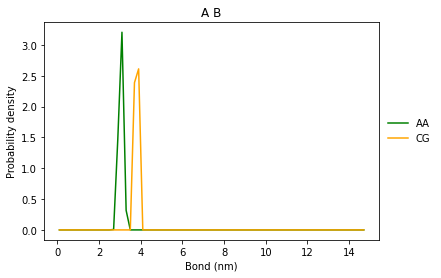

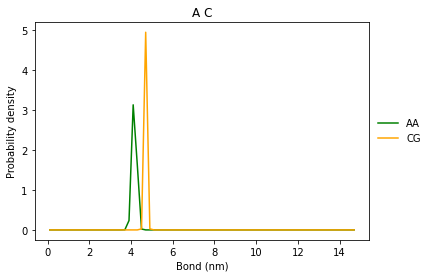

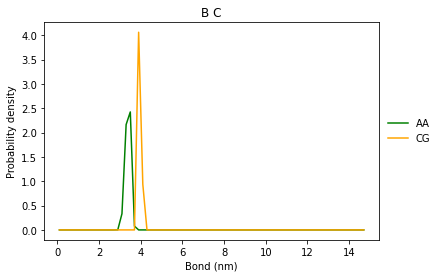

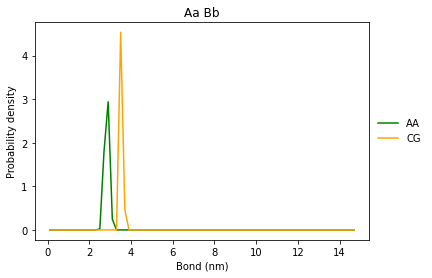

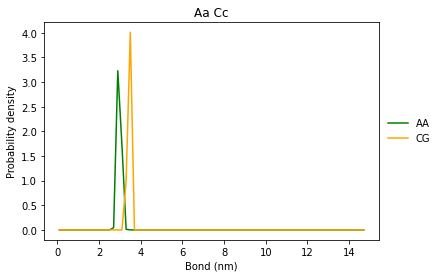

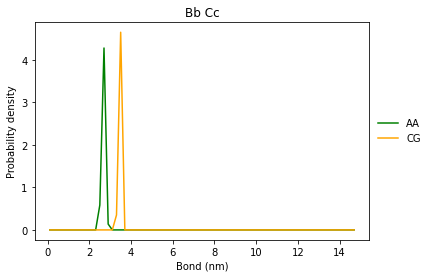

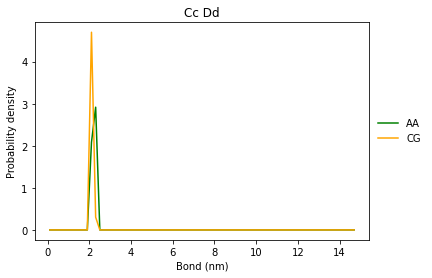

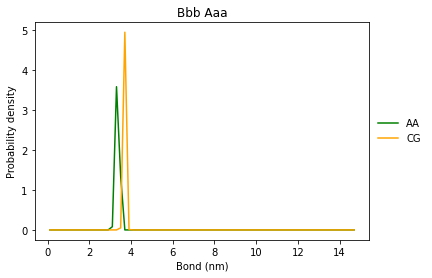

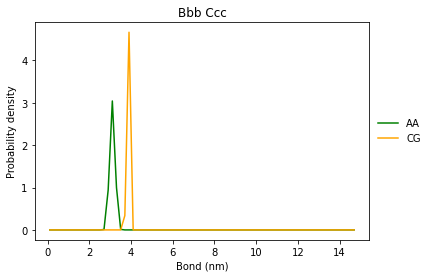

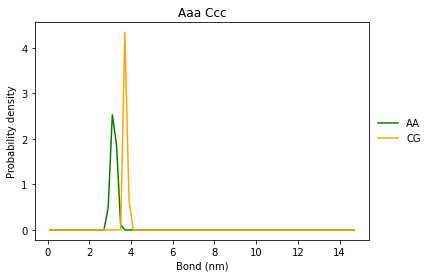

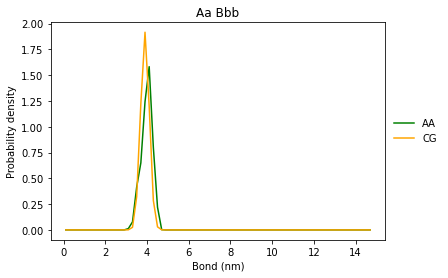

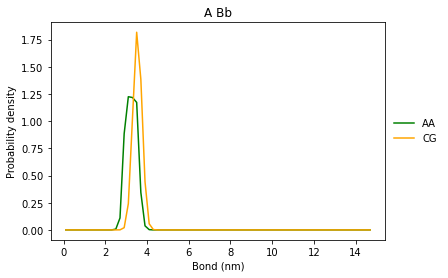

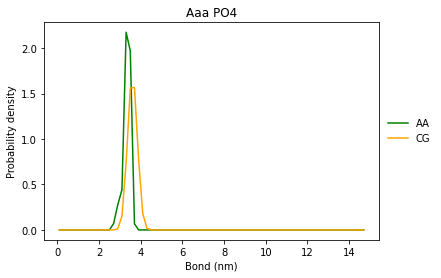

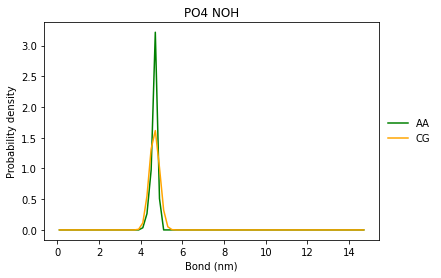

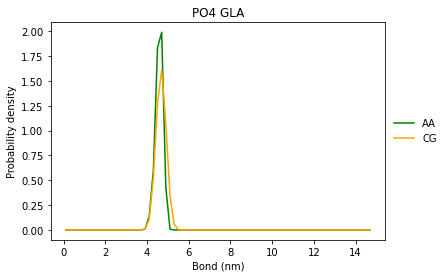

In [51]:
for bond in List_bonds:
    HAA,BAA = np.histogram(np.array(dist_aa)[bond,:], bins=bins_dist, normed=True)
    HCG,BCG = np.histogram(np.array(dist_cg)[bond,:], bins=bins_dist, normed=True)

    plt.plot(bins_dist_x, HAA, label='AA', color='green')
    plt.plot(bins_dist_x, HCG, label='CG', color='orange')

    title = ' '.join(i for i in dist_tgts[bond[0]])
    plt.title(title) 
    plt.xlabel('Bond (nm)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_bond.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_3827366/2367616374.py:2: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  HAA,BAA = np.histogram(np.array(ang_aa)[angle,:], bins=bins_angl, normed=True)
/tmp/ipykernel_3827366/2367616374.py:3: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  HCG,BCG = np.histogram(np.array(ang_cg)[angle,:], bins=bins_angl, normed=True)


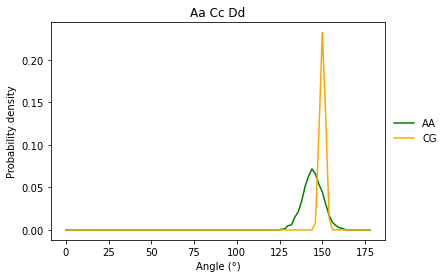

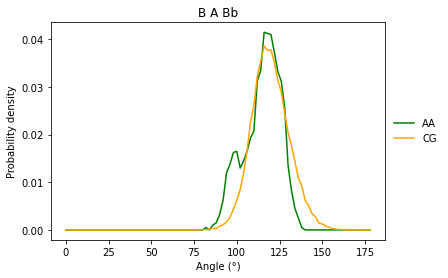

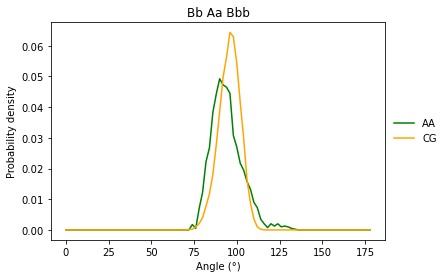

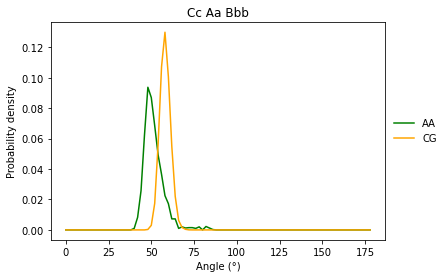

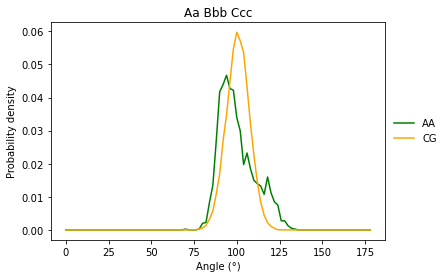

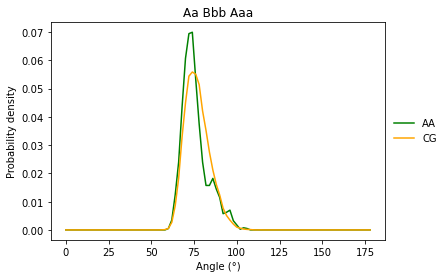

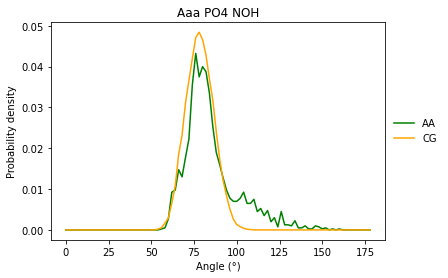

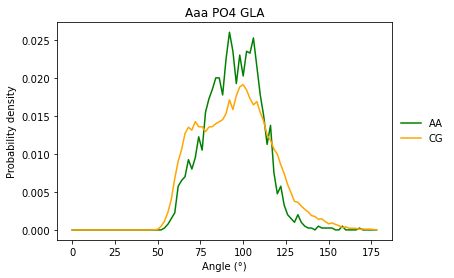

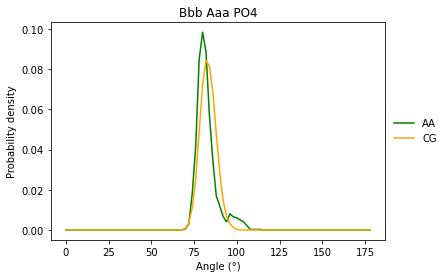

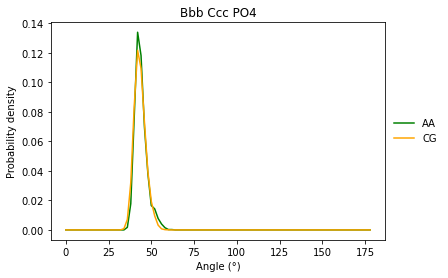

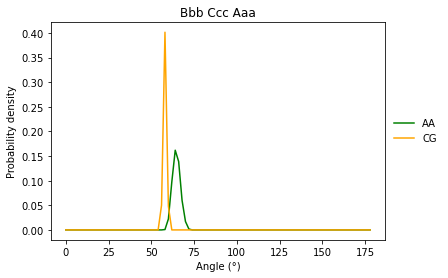

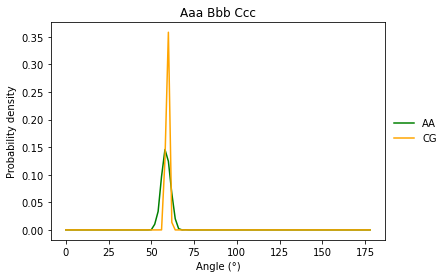

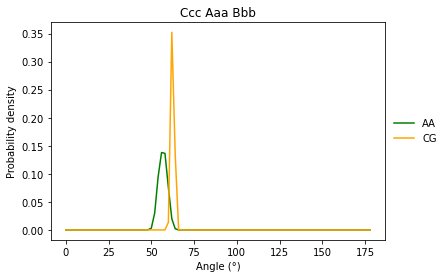

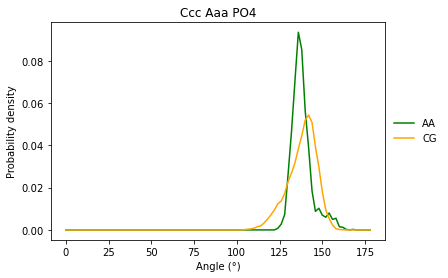

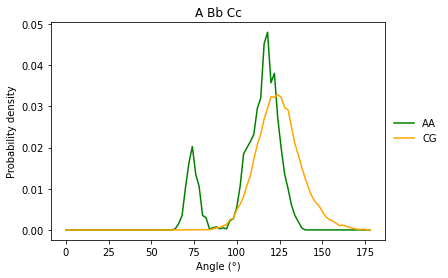

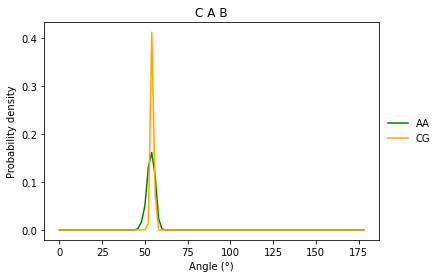

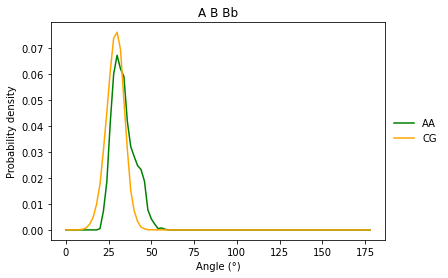

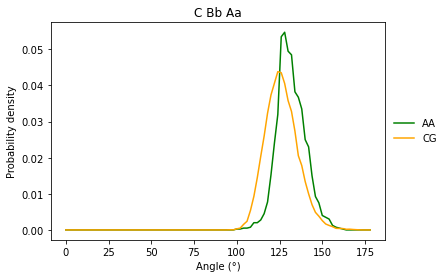

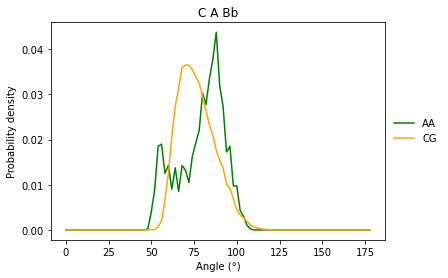

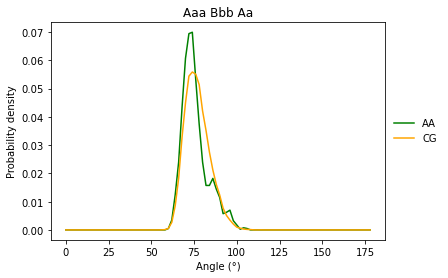

In [52]:
for angle in List_angles:
    HAA,BAA = np.histogram(np.array(ang_aa)[angle,:], bins=bins_angl, normed=True)
    HCG,BCG = np.histogram(np.array(ang_cg)[angle,:], bins=bins_angl, normed=True)

    plt.plot(bins_angl_x, HAA, label='AA', color='green')
    plt.plot(bins_angl_x, HCG, label='CG', color='orange')
    title = ' '.join(i for i in ang_tgts[angle[0]])
    plt.title(title) 
    plt.xlabel('Angle (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_angle.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_3827366/4039917260.py:3: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  HAA,BAA = np.histogram(np.array(dihed_aa)[dihed,:], bins=bins_dihed, normed=True)
/tmp/ipykernel_3827366/4039917260.py:4: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  HCG,BCG = np.histogram(np.array(dihed_cg)[dihed,:], bins=bins_dihed, normed=True)


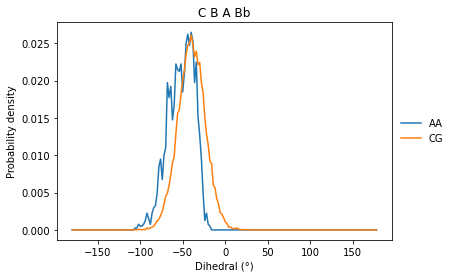

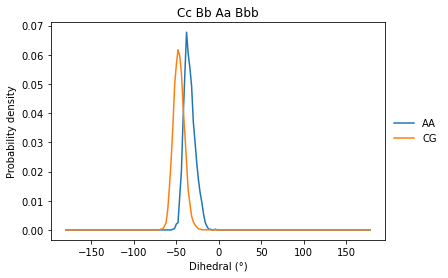

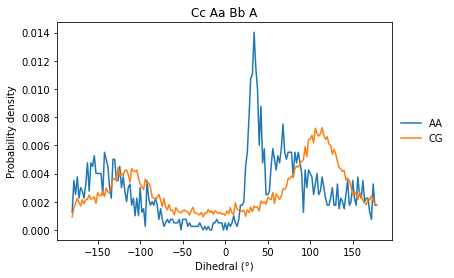

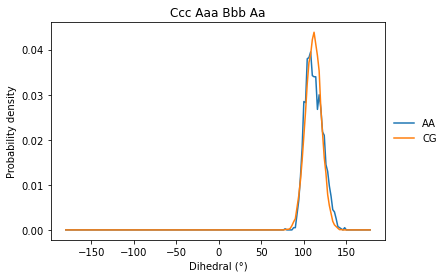

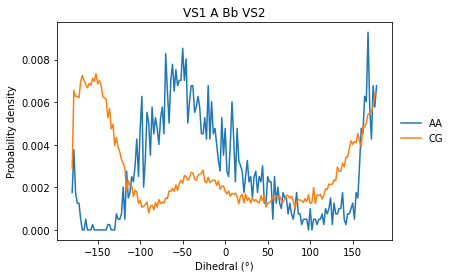

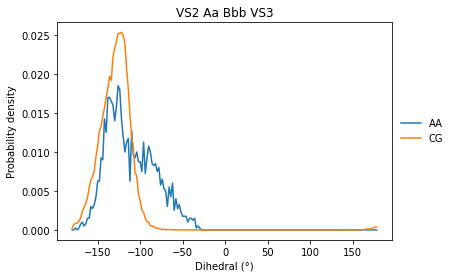

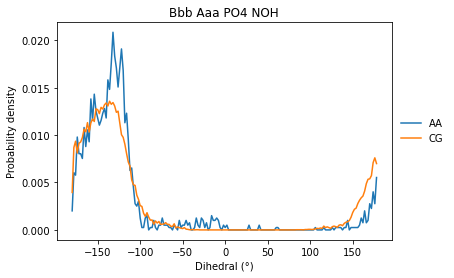

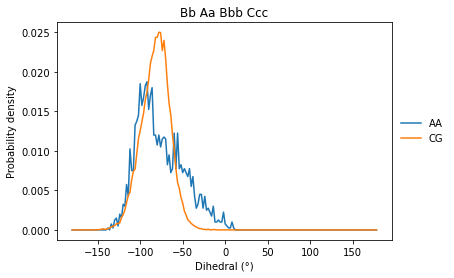

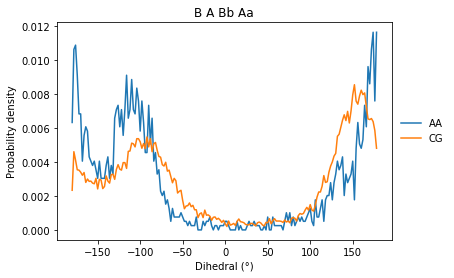

In [53]:
for dihed in List_dihed:

    HAA,BAA = np.histogram(np.array(dihed_aa)[dihed,:], bins=bins_dihed, normed=True)
    HCG,BCG = np.histogram(np.array(dihed_cg)[dihed,:], bins=bins_dihed, normed=True)

    plt.plot(bins_dihed_x, HAA, label='AA')
    plt.plot(bins_dihed_x, HCG, label='CG')
    title = ' '.join(i for i in dihed_tgts[dihed[0]])
    plt.title(title) 
    plt.xlabel('Dihedral (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_dihedral.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

#### you can optimize the bonded parameters now and then re-run. 
Remember to check SASA as well

entering /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/CG_WAT/CG_SASA

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank 

                       :-) GROMACS - gmx sasa, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl    Magnus Lundborg     Erik Marklund   
    Pascal Merz     Pieter Meulenhoff    Teemu Murtola       Szilard Pall   
    Sander Pronk      Roland Schulz      Michael Shirts    Alexey Shvetsov  
   Alfons Sijbers     Peter Tieleman      Jon Vincent      Teemu Virolainen 
 Christian Wennberg    Maarten Wolf      Artem Zhmurov   
                           and the project leaders:
      


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary.

NOTE: From version 5.0 gmx sasa uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- -------- --------

SASA AA: [10.78   0.402]
SASA CG: [9.722 0.169]
percent difference

Last frame     250000 time 750000.000   

Back Off! I just backed up /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/CG_WAT/CG_SASA/resarea_SASA.xvg to /data1/lisbeth/Params/BILAYERS/AA_GIPCs/GIPC_18_1_24_0_membrane_sims/CG_WAT/CG_SASA/#resarea_SASA.xvg.3#
Analyzed 250001 frames, last time 750000.000

GROMACS reminds you: "All You Need is Greed" (Aztec Camera)

                       :-) GROMACS - gmx sasa, 2020.7 (-:

                            GROMACS is written by:
     Emile Apol      Rossen Apostolov      Paul Bauer     Herman J.C. Berendsen
    Par Bjelkmar      Christian Blau   Viacheslav Bolnykh     Kevin Boyd    
 Aldert van Buuren   Rudi van Drunen     Anton Feenstra       Alan Gray     
  Gerrit Groenhof     Anca Hamuraru    Vincent Hindriksen  M. Eric Irrgang  
  Aleksei Iupinov   Christoph Junghans     Joe Jordan     Dimitrios Karkoulis
    Peter Kasson        Jiri Kraus      Carsten Kutzner      Per Larsson    
  Justin A. Lemkul    Viveca Lindahl   

(array([9.722, 0.169]), array([10.78 ,  0.402]))

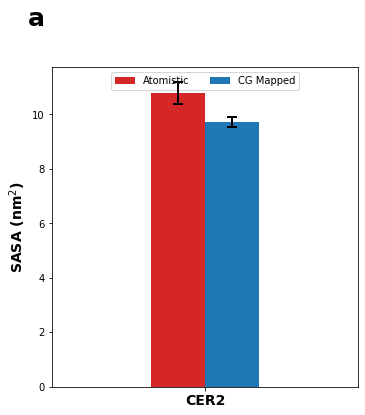

In [54]:
cg_dir =  os.getcwd()

os.chdir(cg_dir)

CG  = ['pbc.gro', #GRO
       'pbc.xtc'] #XTX

run_SASA('CG_SASA', CG, resname, cg_dir, bead_names, bead_sizes)

AA_xvg = '{}/CG_WAT/CG_SASA/resarea_SASA.xvg'.format(main_dir)
CG_xvg = '{}/AA/resarea_SASA.xvg'.format(main_dir)
plot_SASA(AA_xvg, CG_xvg, resname)

In [ ]:
#re_run(resname, mdp_loc, maxwarn=5)

## BL Later once you have fixes CER6 

In [ ]:
os.chdir(main_dir)
os.mkdir('CG_BL')
os.chdir('CG_BL')

In [ ]:
os.system('cp {}/CG_WAT/initial_CG.itp .'.format(main_dir))

In [ ]:
os.system('python2 /data1/lisbeth/PYTHON/insane.py -l A3D:30 -l POPC:70 -pbc cubic -x 5 -y 5 -z 10 -sol W -o mem.gro -p topol.top')

In [ ]:
#os.system("sed -i 's/{}/KC2/g' initial_CG.itp".format(resname))
!rm *.tpr

In [ ]:
prepare_setup_BL('initial_CG.itp', mdp_loc_BL)

In [ ]:
#os.chdir('CG_WAT')
## Open AA   
u_aa = md.Universe('../cg_good.gro',
                   '../cg.xtc')

## Open CG
u_cg = md.Universe('p.gro', 'p.xtc')

##Fragment 
u_frag1 = md.Universe('{}/p.gro'.format(Fragment_dir1), '{}/p.xtc'.format(Fragment_dir1) )
u_frag2 = md.Universe('{}/p.gro'.format(Fragment_dir2), '{}/p.xtc'.format(Fragment_dir2) )

In [ ]:
ang_tgts_frag1 =  [['OH', 'N1','CA'],
             ['OH','N1','CB'],
             ['CA', 'N1', 'CB']
            ]

dist_tgts_frag1 =[
           ['N1', 'OH'],
           ['N1', 'CA'],
           ['N1', 'CB'],
           ]


ang_tgts_frag2 =  [['CA','GLA','CX'],
             ['GLA','CX','C1A'],
             ['GLA', 'CX','C1B'],
             ['C1A','CX','C1B']
            ]

dist_tgts_frag2 =[
           ['CA', 'GLA'],
           ['GLA', 'CX'],
           ['CX','C1A'],
           ['CX', 'C1B'],
           ]

In [ ]:
ang_hist_aa, dist_hist_aa, ang_aa, dist_aa = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_aa, bead_names, resname, 'AA', stride=10)

In [ ]:
ang_hist_cg, dist_hist_cg, ang_cg, dist_cg = measure_bonded_terms_simple(dist_tgts, ang_tgts, u_cg, bead_names, resname, 'CG', stride=10)

In [ ]:
ang_hist_fr1, dist_hist_fr1, ang_fr1, dist_fr1= measure_bonded_terms_simple(dist_tgts_frag1, ang_tgts_frag1,  u_frag1, bead_names, 'UNK', 'AA', stride=1)

In [ ]:
ang_hist_fr2, dist_hist_fr2, ang_fr2, dist_fr2= measure_bonded_terms_simple(dist_tgts_frag2, ang_tgts_frag2,  u_frag2, bead_names, 'LIG', 'AA', stride=1)

In [ ]:
for bond in List_bonds:
#     try:
#         HAAF1,BAAF1 = np.histogram(np.array(dist_fr1)[bond,:], bins=bins_dist, normed=True)
#         HAAF2,BAAF2 = np.histogram(np.array(dist_fr2)[bond,:], bins=bins_dist, normed=True)
#         HAA,BAA = np.histogram(np.array(dist_aa)[bond,:], bins=bins_dist, normed=True)
#         HCG,BCG = np.histogram(np.array(dist_cg)[bond,:], bins=bins_dist, normed=True)

#         plt.plot(bins_dist_x, HAAF1, label='Fragment1', linewidth=3, linestyle='--')
#         plt.plot(bins_dist_x, HAAF2, label='Fragment2', linewidth=1, linestyle='--')
#         plt.plot(bins_dist_x, HAA, label='AA', color='green')
#         plt.plot(bins_dist_x, HCG, label='CG', color='orange')
#     except:
    HAA,BAA = np.histogram(np.array(dist_aa)[bond,:], bins=bins_dist, normed=True)
    HCG,BCG = np.histogram(np.array(dist_cg)[bond,:], bins=bins_dist, normed=True)

    plt.plot(bins_dist_x, HAA, label='AA', color='green')
    plt.plot(bins_dist_x, HCG, label='CG', color='orange')

    title = ' '.join(i for i in dist_tgts[bond[0]])
    plt.title(title) 
    plt.xlabel('Bond (nm)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_bond.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
for angle in List_angles:
#     try:
#         HAAF1,BAAF1 = np.histogram(np.array(ang_fr1)[angle,:], bins=bins_angl, normed=True)
#         HAAF2,BAAF2 = np.histogram(np.array(ang_fr2)[angle,:], bins=bins_angl, normed=True)
#         HAA,BAA = np.histogram(np.array(ang_aa)[angle,:], bins=bins_angl, normed=True)
#         HCG,BCG = np.histogram(np.array(ang_cg)[angle,:], bins=bins_angl, normed=True)

#         plt.plot(bins_dist_x, HAAF1, label='Fragment1', linewidth=3, linestyle='--')
#         plt.plot(bins_dist_x, HAAF2, label='Fragment2', linewidth=1, linestyle='--')
#         plt.plot(bins_dist_x, HAA, label='AA', color='green')
#         plt.plot(bins_dist_x, HCG, label='CG', color='orange')
#     except:
    HAA,BAA = np.histogram(np.array(ang_aa)[angle,:], bins=bins_angl, normed=True)
    HCG,BCG = np.histogram(np.array(ang_cg)[angle,:], bins=bins_angl, normed=True)

    plt.plot(bins_angl_x, HAA, label='AA', color='green')
    plt.plot(bins_angl_x, HCG, label='CG', color='orange')
    title = ' '.join(i for i in ang_tgts[angle[0]])
    plt.title(title) 
    plt.xlabel('Angle (°)')
    plt.ylabel('Probability density')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig('{}_water_angle.png'.format(title), dpi=300, bbox_inches='tight')
    plt.show()

### SASA

In [ ]:
cg_dir =  os.getcwd()

os.chdir(cg_dir)

CG  = ['p_whole.gro', #GRO
       'p_whole.xtc'] #XTX

run_SASA('CG_SASA', CG, resname, cg_dir, bead_names, bead_sizes)

CG_xvg = '{}/CG_BL/CG_SASA/resarea_SASA.xvg'.format(main_dir)
AA_xvg = '{}/AA/resarea_SASA.xvg'.format(main_dir)
plot_SASA(AA_xvg, CG_xvg, resname)

In [ ]:
pwd